# Train XLM-R base intent classifier v2 (Ferman Assistant) — RunPod edition

Trains `xlm-roberta-base` on the **v2 dataset** (`XLMR_dataset_4lang_v2.csv`) —
30 intents instead of the original 60. The dropped intents (music, IoT,
social, audio-volume, qa_stock, unread-mail) needed hardware/OAuth
integrations this app doesn't have; removing them should also raise
Sorani/Badini accuracy since the model no longer has to separate as many
confusable classes with the same amount of dialect data.

**Same four accuracy levers as before** (data augmentation weighted toward
Kurdish, inverse-frequency class weights, label smoothing, early stopping) —
only the dataset and the upload/save steps changed for RunPod.

## RunPod setup (do this once per pod)
1. Deploy a pod from the **RunPod PyTorch template** (any T4/A5000/A100 — this
   model is small, a single mid-tier GPU is plenty).
2. Open the pod's Jupyter Lab link.
3. Upload `XLMR_dataset_4lang_v2.csv` into the same folder as this notebook
   (drag-and-drop in the Jupyter file browser, or `scp`/`runpodctl send`).
4. Run all cells top to bottom.
5. At the end, either download the `xlmr-intent-v2.zip` from the file browser,
   or push straight to the Hugging Face Hub (cell provided, just set your
   token + repo id) so `main.py` can pick it up via `INTENT_REPO`.


In [1]:
!pip install -q transformers datasets accelerate scikit-learn huggingface_hub matplotlib

In [2]:
import random
import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 64          # matches main.py's inference-time max_length
LANGUAGES = ["en", "ar", "sorani", "badini"]   # what the app actually serves

print("GPU available:", torch.cuda.is_available(), "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")


import matplotlib.pyplot as plt

PALETTE = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "savefig.bbox": "tight",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- accuracy-boost knobs ---
EPOCHS = 10                  # upper bound; early stopping halts when val F1 plateaus
LABEL_SMOOTHING = 0.1        # softens over-confident predictions on fuzzy intents
USE_AUGMENTATION = True
USE_CLASS_WEIGHTS = True
# Extra augmented copies to synthesise per TRAIN utterance, per language.
# Kurdish is weakest + most under-represented, so it gets the most; en/ar are
# left as-is to avoid diluting their already-strong signal.
AUG_PER_LANG = {"badini": 3, "sorani": 3, "ar": 0, "en": 0}
CLASS_WEIGHT_POWER = 0.5     # <1 softens inverse-frequency weighting
                             # (1.0 = full strength, 0 = uniform). Tames
                             # over-prediction of rare intents + recovers
                             # some Arabic accuracy while keeping Kurdish gains.

GPU available: True - NVIDIA GeForce RTX 4090


## 1. Load the dataset

`XLMR_dataset_4lang_v2.csv` must already be sitting next to this notebook
(uploaded via Jupyter Lab's file browser — no Colab upload widget needed on
RunPod).

In [3]:
CSV_PATH = "XLMR_dataset_4lang_v2.csv"

df = pd.read_csv(CSV_PATH)
df = df[df["language"].isin(LANGUAGES)].reset_index(drop=True)
print(df.shape)
print(df["language"].value_counts())
print(df["partition"].value_counts())
print(df["intent"].nunique(), "intents")

assert df["utt"].isna().sum() == 0, "found null utterances"
assert df["intent"].isna().sum() == 0, "found null intents"

(27445, 5)
language
en        11097
ar        11097
sorani     2626
badini     2625
Name: count, dtype: int64
partition
train         19635
test           4648
validation     3162
Name: count, dtype: int64
34 intents


### Dataset overview

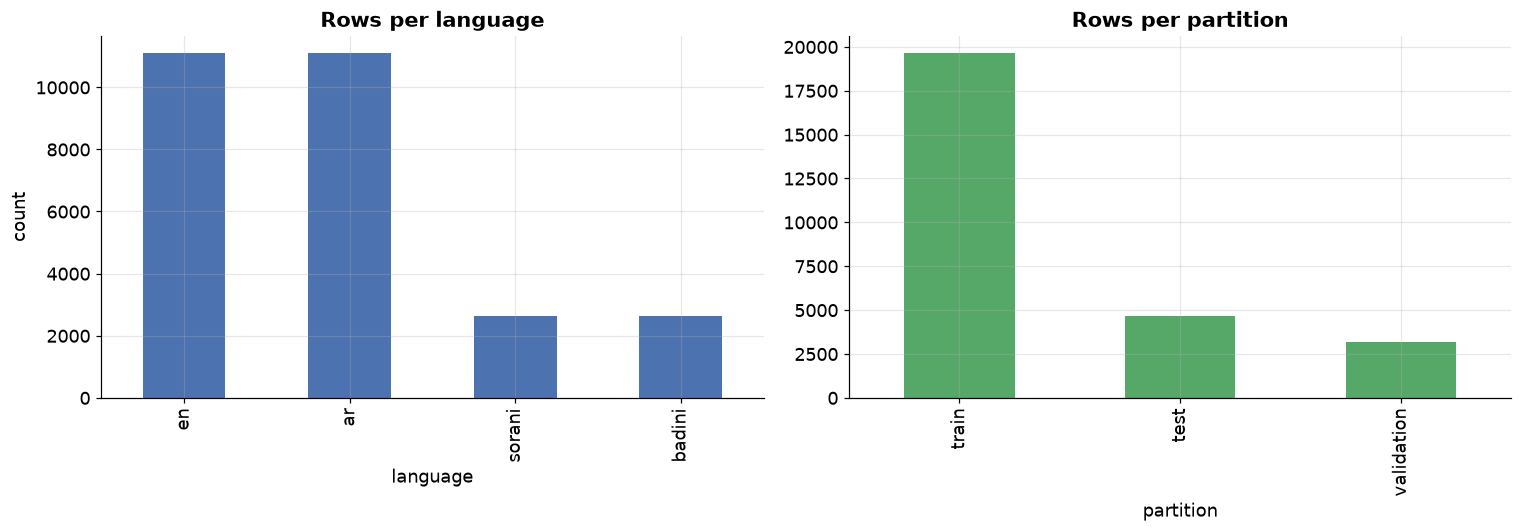

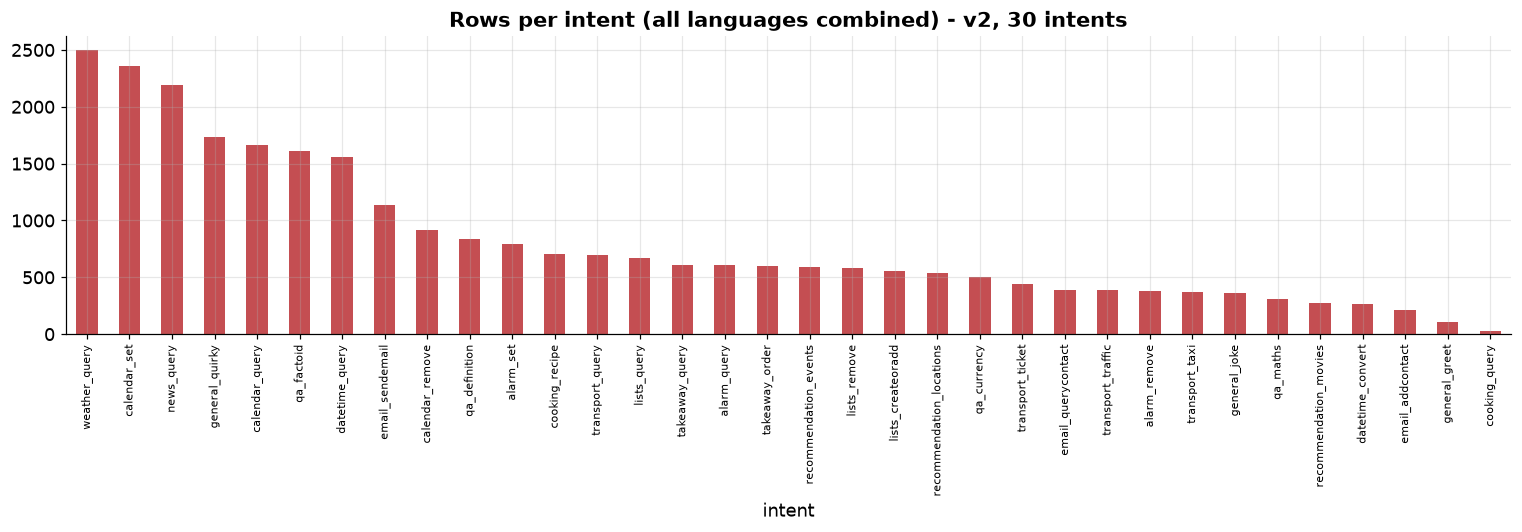

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["language"].value_counts().plot(kind="bar", ax=axes[0], color=PALETTE[0])
axes[0].set_title("Rows per language")
axes[0].set_ylabel("count")

df["partition"].value_counts().plot(kind="bar", ax=axes[1], color=PALETTE[1])
axes[1].set_title("Rows per partition")

plt.tight_layout()
plt.savefig("chart_dataset_overview.png")
plt.show()

plt.figure(figsize=(14, 5))
df["intent"].value_counts().plot(kind="bar", color=PALETTE[2])
plt.title("Rows per intent (all languages combined) - v2, 30 intents")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig("chart_intent_distribution.png")
plt.show()

## 2. Build label mappings

In [5]:
labels = sorted(df["intent"].unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for i, l in enumerate(labels)}
print(f"{len(labels)} intents")

df["label"] = df["intent"].map(label2id)

34 intents


## 2b. Data augmentation (training set only)

Random **word deletion** and **adjacent word swap** — both script-agnostic, so
they work on Arabic-script Kurdish. Applied only to `train` (never validation /
test, which must stay clean), and only to the languages in `AUG_PER_LANG`.

train rows: 19635 -> after augmentation: 27418
          before  after
language               
ar          7753   7466
badini      2064   6236
en          7753   7753
sorani      2065   5963


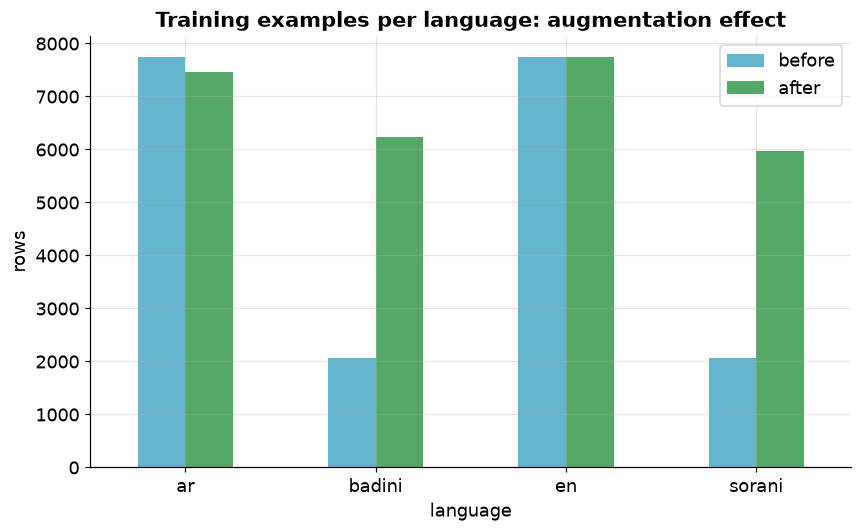

In [6]:
import random as _rnd

def _random_deletion(words, p=0.15):
    if len(words) <= 3:
        return words
    kept = [w for w in words if _rnd.random() > p]
    return kept or [_rnd.choice(words)]

def _random_swap(words, n=1):
    words = words[:]
    for _ in range(n):
        if len(words) < 2:
            break
        j = _rnd.randint(0, len(words) - 2)
        words[j], words[j + 1] = words[j + 1], words[j]
    return words

def augment_text(text):
    words = text.split()
    if len(words) < 2:
        return text
    if _rnd.random() < 0.5:
        words = _random_deletion(words)
    else:
        words = _random_swap(words, n=max(1, len(words) // 5))
    return " ".join(words)

train_df = df[df["partition"] == "train"].copy()

if USE_AUGMENTATION:
    _rnd.seed(SEED)
    aug_rows = []
    for lang, factor in AUG_PER_LANG.items():
        sub = train_df[train_df["language"] == lang]
        for _ in range(factor):
            for _, r in sub.iterrows():
                aug_rows.append({
                    "language": lang, "partition": "train",
                    "intent": r["intent"], "utt": augment_text(r["utt"]),
                    "label": r["label"],
                })
    aug_df = pd.DataFrame(aug_rows)
    train_aug = (
        pd.concat([train_df, aug_df], ignore_index=True)
        .drop_duplicates(subset=["language", "intent", "utt"])
        .reset_index(drop=True)
    )
else:
    train_aug = train_df

print("train rows:", len(train_df), "-> after augmentation:", len(train_aug))

before = train_df["language"].value_counts().sort_index()
after = train_aug["language"].value_counts().sort_index()
comp = pd.DataFrame({"before": before, "after": after}).fillna(0).astype(int)
print(comp)

ax = comp.plot(kind="bar", figsize=(8, 5), color=[PALETTE[5], PALETTE[1]])
ax.set_title("Training examples per language: augmentation effect")
ax.set_ylabel("rows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart_augmentation.png")
plt.show()

## 3. Build train/validation/test splits

Using the dataset's own `partition` column rather than re-splitting.

In [7]:
from datasets import Dataset, DatasetDict

def to_ds(frame):
    return Dataset.from_pandas(frame[["utt", "label", "language"]].reset_index(drop=True))

raw = DatasetDict({
    "train": to_ds(train_aug),
    "validation": to_ds(df[df["partition"] == "validation"]),
    "test": to_ds(df[df["partition"] == "test"]),
})
raw

DatasetDict({
    train: Dataset({
        features: ['utt', 'label', 'language'],
        num_rows: 27418
    })
    validation: Dataset({
        features: ['utt', 'label', 'language'],
        num_rows: 3162
    })
    test: Dataset({
        features: ['utt', 'label', 'language'],
        num_rows: 4648
    })
})

## 4. Tokenize

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["utt"], truncation=True, max_length=MAX_LENGTH)

tokenized = raw.map(tokenize, batched=True, remove_columns=["utt"])

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/27418 [00:00<?, ? examples/s]

Map:   0%|          | 0/3162 [00:00<?, ? examples/s]

Map:   0%|          | 0/4648 [00:00<?, ? examples/s]

## 5. Model + Trainer

In [9]:
import torch.nn as nn
from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, f1_score

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }

# Inverse-frequency class weights from the (augmented) training labels.
train_labels = np.array(tokenized["train"]["label"])
counts = np.bincount(train_labels, minlength=len(labels))
inv = counts.sum() / (len(labels) * np.maximum(counts, 1))
inv = inv ** CLASS_WEIGHT_POWER     # soften: gentler up-weighting of rare intents
inv = inv / inv.mean()              # normalise to mean 1 so the loss scale is stable
class_weights = torch.tensor(inv, dtype=torch.float) if USE_CLASS_WEIGHTS else None

class WeightedTrainer(Trainer):
    # CrossEntropy with optional class weights + label smoothing.
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        target = inputs.pop("labels")
        outputs = model(**inputs)
        weight = class_weights.to(outputs.logits.device) if class_weights is not None else None
        loss_fct = nn.CrossEntropyLoss(weight=weight, label_smoothing=LABEL_SMOOTHING)
        loss = loss_fct(outputs.logits.view(-1, model.config.num_labels), target.view(-1))
        return (loss, outputs) if return_outputs else loss

args = TrainingArguments(
    output_dir="./xlmr-intent-v2-run",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

## 6. Train

In [10]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.205126,1.985821,0.648324,0.495700
2,1.477345,1.493083,0.805819,0.765307
3,1.268479,1.449171,0.812460,0.788128
4,1.183167,1.414590,0.834282,0.817255
5,1.086675,1.402039,0.837445,0.812885
6,1.064827,1.414854,0.839026,0.822417
7,1.051912,1.417349,0.848197,0.830462
8,1.003576,1.442514,0.846932,0.827988
9,0.980534,1.435122,0.844402,0.831939
10,0.956545,1.435503,0.846616,0.834319


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8570, training_loss=1.3494469180824877, metrics={'train_runtime': 633.0657, 'train_samples_per_second': 433.099, 'train_steps_per_second': 13.537, 'total_flos': 5243560177139568.0, 'train_loss': 1.3494469180824877, 'epoch': 10.0})

### Training curves

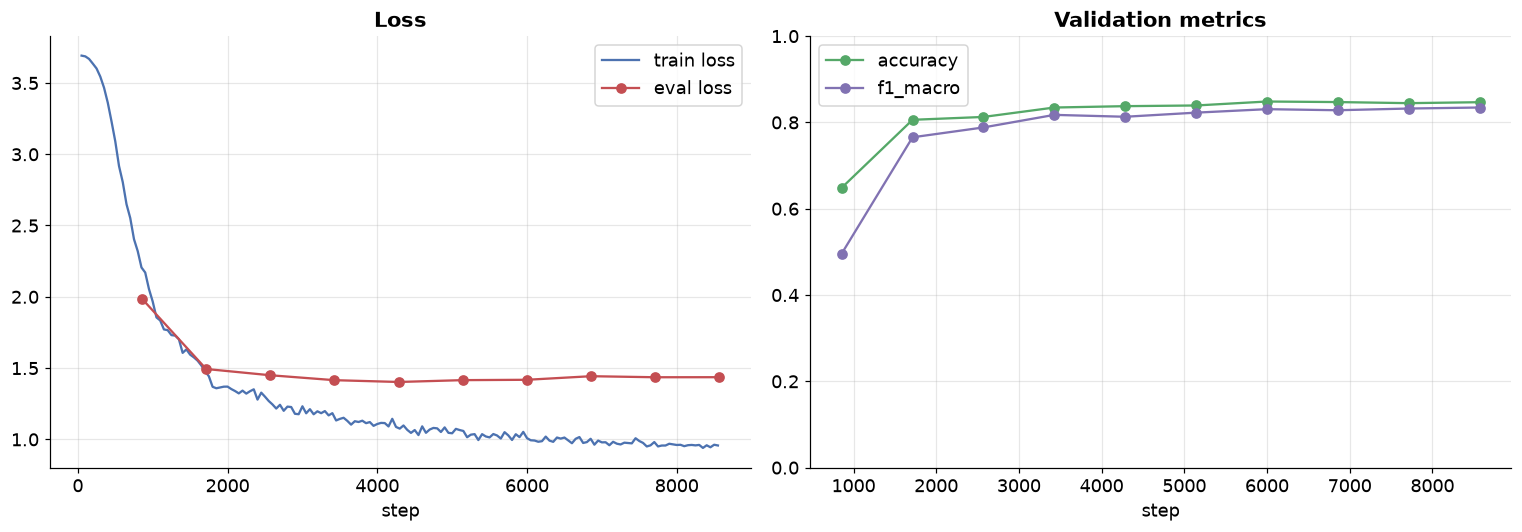

In [11]:
history = trainer.state.log_history
train_points = [(h["step"], h["loss"]) for h in history if "loss" in h]
eval_points = [h for h in history if "eval_loss" in h]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if train_points:
    steps, losses = zip(*train_points)
    axes[0].plot(steps, losses, label="train loss", color=PALETTE[0])
if eval_points:
    axes[0].plot([h["step"] for h in eval_points], [h["eval_loss"] for h in eval_points],
                 label="eval loss", marker="o", color=PALETTE[2])
axes[0].set_xlabel("step")
axes[0].set_title("Loss")
axes[0].legend()

if eval_points:
    axes[1].plot([h["step"] for h in eval_points], [h["eval_accuracy"] for h in eval_points],
                 label="accuracy", marker="o", color=PALETTE[1])
    axes[1].plot([h["step"] for h in eval_points], [h["eval_f1_macro"] for h in eval_points],
                 label="f1_macro", marker="o", color=PALETTE[3])
axes[1].set_xlabel("step")
axes[1].set_ylim(0, 1)
axes[1].set_title("Validation metrics")
axes[1].legend()

plt.tight_layout()
plt.savefig("chart_training_curves.png")
plt.show()

## 7. Evaluate on the held-out test set

In [12]:
from sklearn.metrics import classification_report

test_pred = trainer.predict(tokenized["test"])
y_true = test_pred.label_ids
y_pred = np.argmax(test_pred.predictions, axis=-1)

print("test accuracy:", accuracy_score(y_true, y_pred))
print("test f1_macro:", f1_score(y_true, y_pred, average="macro"))
print()
print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))

test accuracy: 0.8319707401032702
test f1_macro: 0.790298361546228

                          precision    recall  f1-score   support

             alarm_query       0.92      0.88      0.90        90
            alarm_remove       0.89      0.95      0.92        66
               alarm_set       0.81      0.93      0.87       106
          calendar_query       0.73      0.75      0.74       274
         calendar_remove       0.84      0.87      0.85       152
            calendar_set       0.95      0.85      0.90       438
           cooking_query       0.00      0.00      0.00         0
          cooking_recipe       0.88      0.83      0.85       166
        datetime_convert       0.89      0.77      0.82        52
          datetime_query       0.87      0.94      0.91       198
        email_addcontact       0.69      0.79      0.74        48
      email_querycontact       0.75      0.84      0.79        70
         email_sendemail       0.98      0.95      0.96       248
       

### Performance breakdown: by language, confusion matrix, by intent

  language  accuracy  f1_macro       n
0       ar  0.823439  0.761227  1954.0
1   badini  0.718919  0.682428   370.0
2       en  0.887410  0.848391  1954.0
3   sorani  0.697297  0.646455   370.0


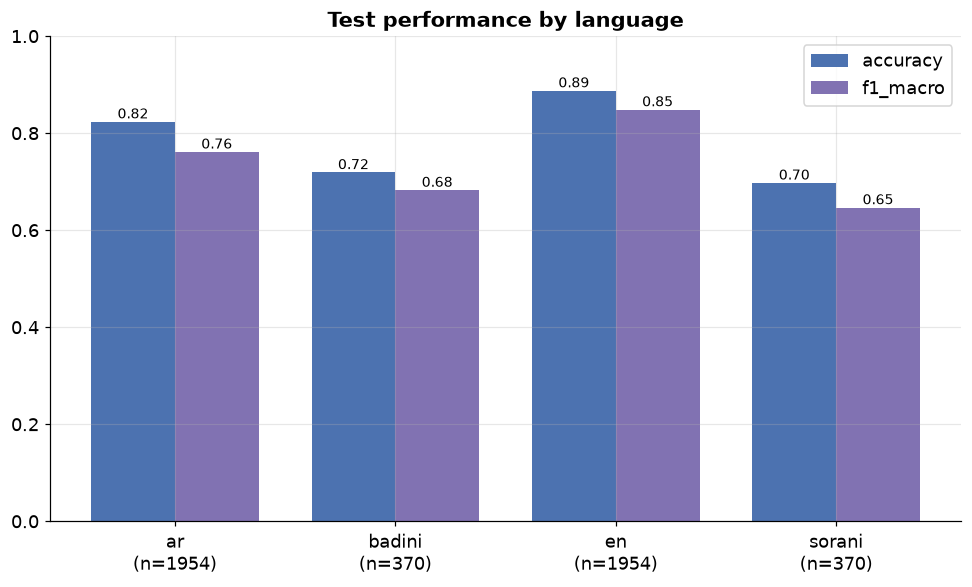

In [13]:
# --- Performance by language (the key view for a Kurdish-focused app) ---
languages = tokenized["test"]["language"]
per_lang = pd.DataFrame({"language": languages, "true": y_true, "pred": y_pred})
lang_metrics = per_lang.groupby("language").apply(
    lambda g: pd.Series({
        "accuracy": accuracy_score(g["true"], g["pred"]),
        "f1_macro": f1_score(g["true"], g["pred"], average="macro"),
        "n": len(g),
    }),
    include_groups=False,
).reset_index()
print(lang_metrics)

xs = np.arange(len(lang_metrics))
width = 0.38
fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(xs - width / 2, lang_metrics["accuracy"], width, label="accuracy", color=PALETTE[0])
b2 = ax.bar(xs + width / 2, lang_metrics["f1_macro"], width, label="f1_macro", color=PALETTE[3])
ax.set_xticks(xs)
ax.set_xticklabels([f"{l}\n(n={int(n)})" for l, n in zip(lang_metrics["language"], lang_metrics["n"])])
ax.set_ylim(0, 1)
ax.set_title("Test performance by language")
ax.legend()
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.2f}", (bar.get_x() + bar.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("chart_language_performance.png")
plt.show()

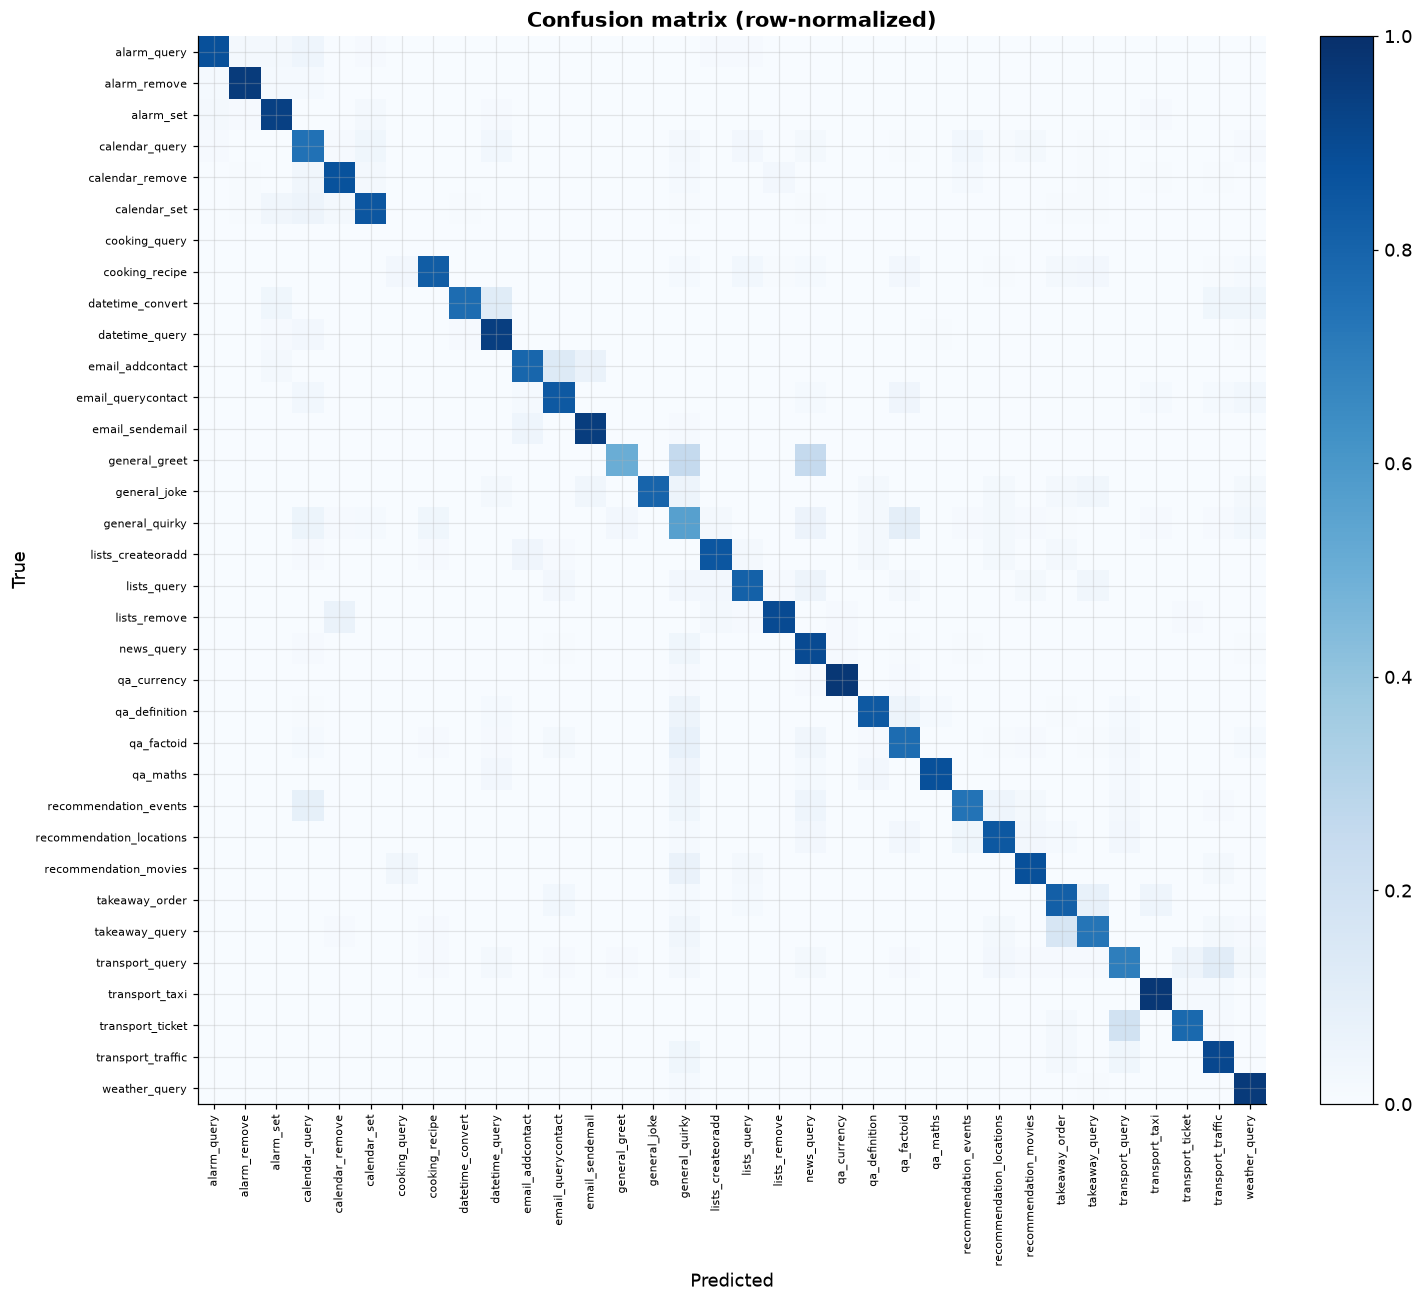

In [14]:
# --- Confusion matrix (row-normalized: each row sums to 1 = recall per intent) ---
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)), normalize="true")

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (row-normalized)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("chart_confusion_matrix.png")
plt.show()

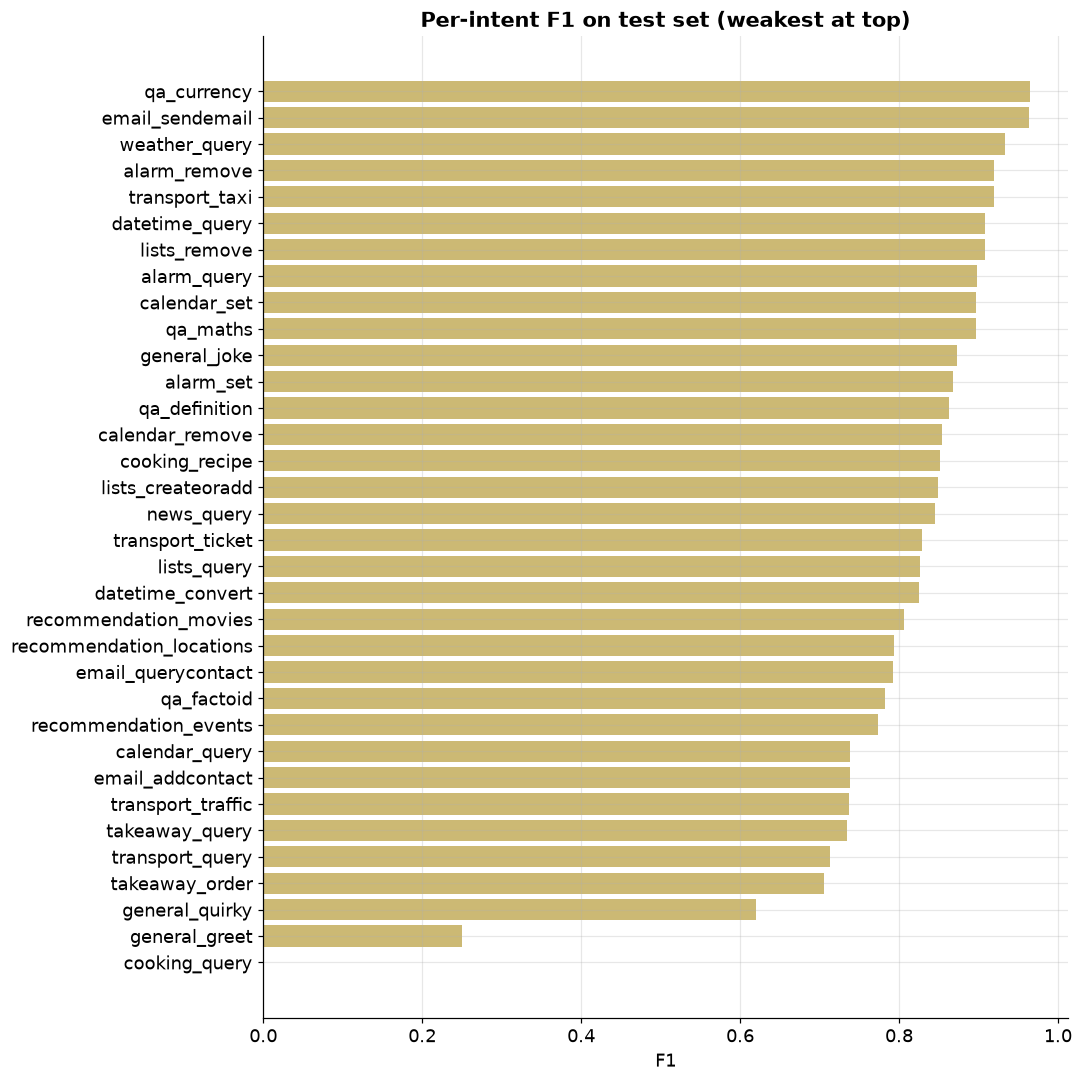

Top confused (true -> predicted) pairs:
  general_quirky -> qa_factoid: 34
  calendar_set -> calendar_query: 22
  qa_factoid -> general_quirky: 22
  general_quirky -> news_query: 20
  general_quirky -> calendar_query: 19
  transport_ticket -> transport_query: 17
  takeaway_query -> takeaway_order: 15
  calendar_set -> alarm_set: 15
  transport_query -> transport_traffic: 14
  general_quirky -> cooking_recipe: 13


In [15]:
# --- Per-intent F1 (weakest at top) + most-confused pairs ---
from collections import Counter

per_intent_f1 = f1_score(y_true, y_pred, average=None, labels=range(len(labels)))
order = np.argsort(per_intent_f1)

plt.figure(figsize=(10, 10))
plt.barh([labels[i] for i in order], per_intent_f1[order], color=PALETTE[4])
plt.xlabel("F1")
plt.title("Per-intent F1 on test set (weakest at top)")
plt.tight_layout()
plt.savefig("chart_per_intent_f1.png")
plt.show()

confusions = Counter()
for t, p in zip(y_true, y_pred):
    if t != p:
        confusions[(labels[t], labels[p])] += 1
print("Top confused (true -> predicted) pairs:")
for (t, p), n in confusions.most_common(10):
    print(f"  {t} -> {p}: {n}")

## 8. Save the model

Saved in the same layout as the current `xlmr-intent/` folder (`config.json`
with `id2label`/`label2id`, `model.safetensors`, tokenizer files) so it's a
drop-in replacement — no changes needed in `main.py`.

In [16]:
SAVE_DIR = "xlmr-intent-v2"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("Saved to", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to xlmr-intent-v2


## 9. Get the model out of the pod

Two options — pick whichever fits your workflow:

**A. Zip + download via Jupyter Lab's file browser** (left sidebar → find
`xlmr-intent-v2.zip` → right-click → Download). Good for a quick local copy.

In [ ]:
!zip -rq xlmr-intent-v2.zip xlmr-intent-v2
print("Ready: xlmr-intent-v2.zip (download it from the Jupyter file browser)")

**B. Push straight to the Hugging Face Hub (recommended).** This is what
`main.py` reads via the `INTENT_REPO` env var (see `main.py`'s `_source()` /
`load_models()`), so pushing here means your deployed backend picks it up
with just an env var change, no manual file copying to the server.

Set `HF_TOKEN` (a Hub token with write access, from huggingface.co/settings/tokens)
and `HF_REPO_ID` (e.g. `your-username/xlmr-intent-v2`) below, then run.

In [ ]:
import os
from huggingface_hub import login, HfApi

HF_TOKEN = os.environ.get("HF_TOKEN", "")     # or paste your token directly (don't commit it!)
HF_REPO_ID = "your-username/xlmr-intent-v2"   # change this

if HF_TOKEN:
    login(token=HF_TOKEN)
    HfApi().create_repo(repo_id=HF_REPO_ID, repo_type="model", exist_ok=True)
    HfApi().upload_folder(folder_path=SAVE_DIR, repo_id=HF_REPO_ID, repo_type="model")
    print(f"Pushed to https://huggingface.co/{HF_REPO_ID}")
    print(f"Set INTENT_REPO={HF_REPO_ID} on your backend (Cloud Run env var) to use it.")
else:
    print("Set HF_TOKEN above to push to the Hub, or skip this cell and use the zip download instead.")